# Regression and generalized linear models

How one idea - a linear predictor $\eta = \beta^\top x$ - covers continuous, binary, and count responses by changing the link function and the outcome distribution: ordinary linear regression (identity link, Gaussian), logistic regression (logit link, Bernoulli), and Poisson regression (log link). In `mixle.ppl` each is the same one-liner with a different outer family, fit by the same machinery.


## Linear models and the Gauss-Markov theorem

The linear model is $y = X\beta + \varepsilon$ with $\mathbb E[\varepsilon]=0$ and
$\mathrm{Cov}(\varepsilon)=\sigma^2 I$. The least-squares estimator is $\hat\beta=(X^\top X)^{-1}X^\top y$.

Theorem (Gauss-Markov). Among all linear unbiased estimators of $\beta$, ordinary least squares has the
smallest variance: it is the best linear unbiased estimator (BLUE). No normality assumption is needed,
only uncorrelated, equal-variance errors.

Proof. Any linear unbiased estimator is $\tilde\beta=Cy$ with $\mathbb E[\tilde\beta]=CX\beta=\beta$ for
all $\beta$, so $CX=I$. Write $C=(X^\top X)^{-1}X^\top + D$; then $CX=I$ forces $DX=0$. Its covariance is
$\sigma^2 CC^\top = \sigma^2\big((X^\top X)^{-1} + DD^\top\big)$, since the cross term
$(X^\top X)^{-1}X^\top D^\top = (X^\top X)^{-1}(DX)^\top = 0$. As $DD^\top\succeq 0$, the OLS covariance
$\sigma^2(X^\top X)^{-1}$ is smallest in the positive-semidefinite order. $\quad\blacksquare$

## Generalized linear models

When the response is binary, a count, or otherwise non-Gaussian, the linear model is the wrong likelihood.
A generalized linear model (GLM) keeps a linear predictor but adapts the distribution and the scale.

Definition (GLM). The response has an exponential-family distribution with mean $\mu$, related to a linear
predictor through a link $g$: $g(\mu)=\eta=x^\top\beta$. Logistic regression uses the Bernoulli with the
logit link $g(\mu)=\log\tfrac{\mu}{1-\mu}$; Poisson regression uses the log link $g(\mu)=\log\mu$. The
canonical link is the one for which $\eta$ equals the natural parameter of the family.

Theorem (concavity under the canonical link). With the canonical link the GLM log-likelihood is concave
in $\beta$, so the maximum-likelihood estimate is unique and is found by Fisher scoring, which here is
iteratively reweighted least squares (IRLS).

Proof. For the canonical link the log-likelihood gradient is $X^\top(y-\mu)$ and the Hessian is
$-X^\top W X$ with $W=\mathrm{diag}(\mathrm{Var}(y_i))\succeq 0$ (for logistic, $W_{ii}=\mu_i(1-\mu_i)$).
A Hessian of the form $-X^\top W X$ is negative semidefinite, so the objective is concave; it is strictly
concave when $X$ has full column rank, giving a unique maximizer. $\quad\blacksquare$

Counterexample (OLS on the wrong response). Fitting OLS to a binary outcome (the linear probability
model) predicts probabilities outside $[0,1]$ and assumes constant error variance when the true variance
$\mu(1-\mu)$ depends on the mean; for counts it can predict negatives. The link and likelihood exist
precisely to prevent this, as the held-out comparison in this notebook shows. We verify the concavity
claim numerically below.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.ppl import Normal, Bernoulli, Poisson, Field, free
rng = np.random.RandomState(0)

## 1. Linear regression: identity link, Gaussian noise

The base case: a continuous response with $y = \beta x + \alpha + \varepsilon$, $\varepsilon\sim\mathcal N(0,\sigma^2)$. The linear predictor is the mean. In `mixle.ppl`, `Normal(free*Field('x') + free, free)` - coefficients are `free`, the covariate enters via `Field`, the response goes in positionally and covariates via `given=`.


linear coeffs: {'x': 1.95, 'intercept': -1.08} (true slope 2, intercept -1)


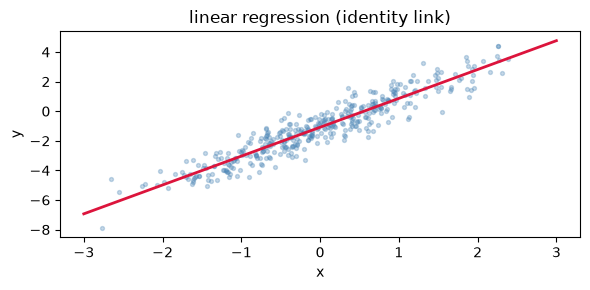

In [2]:
x = rng.normal(0, 1, 400); y = 2.0 * x - 1.0 + rng.normal(0, 0.7, 400)
lin = Normal(free * Field('x') + free, free).fit(list(y), given={'x': list(x)})
print('linear coeffs:', {k: round(v['mean'], 2) for k, v in lin.result.coefficients.items()}, '(true slope 2, intercept -1)')

grid = np.linspace(-3, 3, 50)
fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(x, y, s=8, alpha=0.3, color='steelblue')
ax.plot(grid, np.asarray(lin.result.predict({'x': list(grid)})), color='crimson', lw=2)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('linear regression (identity link)')
plt.tight_layout(); plt.show()

## 2. The GLM idea: link + family

A generalized linear model keeps the linear predictor $\eta=\beta^\top x$ but passes it through a link so the mean lands in the right range, and swaps the Gaussian for the family that matches the response:

| response | family | link | mean = |
|---|---|---|---|
| continuous | Gaussian | identity | $\eta$ |
| binary (0/1) | Bernoulli | logit | $\sigma(\eta)=1/(1+e^{-\eta})$ |
| count (0,1,2,…) | Poisson | log | $e^{\eta}$ |

The outer family in `mixle.ppl` sets both - `Bernoulli(...)` gives logistic regression, `Poisson(...)` gives Poisson regression - with no other change. We fit both.


logistic coeffs: {'z': 1.73, 'intercept': -0.69} (true 1.5, -0.5)
Poisson coeffs : {'w': 0.6, 'intercept': 0.49} (true 0.6, 0.5)


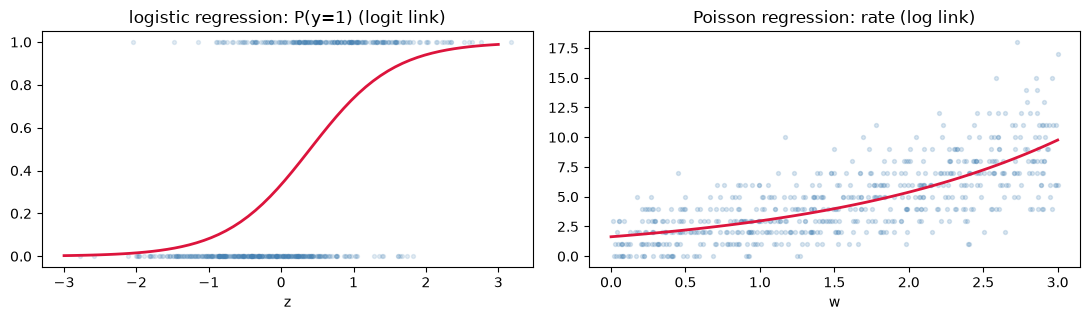

In [3]:
# logistic regression: P(y=1) = sigmoid(1.5 z - 0.5)
z = rng.normal(0, 1, 600); pz = 1 / (1 + np.exp(-(1.5 * z - 0.5))); yb = (rng.random(600) < pz).astype(float)
logit = Bernoulli(free * Field('z') + free).fit(list(yb), given={'z': list(z)})
print('logistic coeffs:', {k: round(v['mean'], 2) for k, v in logit.result.coefficients.items()}, '(true 1.5, -0.5)')

# Poisson regression: rate = exp(0.5 + 0.6 w)
w = rng.uniform(0, 3, 600); yc = rng.poisson(np.exp(0.5 + 0.6 * w)).astype(float)
pois = Poisson(free * Field('w') + free).fit(list(yc), given={'w': list(w)})
print('Poisson coeffs :', {k: round(v['mean'], 2) for k, v in pois.result.coefficients.items()}, '(true 0.6, 0.5)')

gz = np.linspace(-3, 3, 60); gw = np.linspace(0, 3, 60)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].scatter(z, yb, s=8, alpha=0.15, color='steelblue')
ax[0].plot(gz, np.asarray(logit.result.predict({'z': list(gz)})), color='crimson', lw=2)
ax[0].set_title('logistic regression: P(y=1) (logit link)'); ax[0].set_xlabel('z')
ax[1].scatter(w, yc, s=8, alpha=0.2, color='steelblue')
ax[1].plot(gw, np.asarray(pois.result.predict({'w': list(gw)})), color='crimson', lw=2)
ax[1].set_title('Poisson regression: rate (log link)'); ax[1].set_xlabel('w')
plt.tight_layout(); plt.show()

## 3. Choosing the GLM, and why the link matters

Match the family to the response: continuous → linear, binary → logistic, counts → Poisson (and negative binomial if overdispersed, see count_data_overdispersion). The link keeps predictions valid - a logit link can never predict a probability outside $[0,1]$, a log link never a negative rate - which a plain linear model on the same data would violate. The coefficients are then read on the link scale: a unit change in $x$ adds $\beta$ to the log-odds (logistic) or the log-rate (Poisson), i.e. multiplies the odds/rate by $e^\beta$.


In [4]:
b = logit.result.coefficients['z']['mean']
print('logistic: each +1 in z multiplies the odds of y=1 by e^%.2f = %.2f' % (b, np.exp(b)))
bp = pois.result.coefficients['w']['mean']
print('Poisson : each +1 in w multiplies the expected count by e^%.2f = %.2f' % (bp, np.exp(bp)))

logistic: each +1 in z multiplies the odds of y=1 by e^1.73 = 5.61
Poisson : each +1 in w multiplies the expected count by e^0.60 = 1.81


## The link/likelihood must match the data

A GLM is not just "regression with a curve" - choosing the right likelihood is what makes predictions and uncertainty valid. A Poisson GLM ties the variance to the mean (the count is more variable where the rate is high), while an OLS fit assumes constant noise everywhere. We split the count data, fit both, and compare held-out predictive log-likelihood (the honest scoring rule) - the correct likelihood scores higher on unseen data.


In [5]:
from scipy import stats as _st
tr = slice(0, 400); te = slice(400, 600)
pois_te = Poisson(free * Field('w') + free).fit(list(yc[tr]), given={'w': list(w[tr])})
norm_te = Normal(free * Field('w') + free, free).fit(list(yc[tr]), given={'w': list(w[tr])})
rate = np.asarray(pois_te.result.predict({'w': list(w[te])}))      # Poisson predict -> mean rate (exp link)
ll_pois = _st.poisson.logpmf(yc[te], rate).mean()
mu = np.asarray(norm_te.result.predict({'w': list(w[te])}))
sd = np.std(np.asarray(yc[tr]) - np.asarray(norm_te.result.predict({'w': list(w[tr])})))
ll_norm = _st.norm.logpdf(yc[te], mu, sd).mean()
print('held-out mean log-likelihood   Poisson GLM: %.3f   Gaussian/OLS: %.3f' % (ll_pois, ll_norm))
resid = np.asarray(yc[te]) - mu
corr = np.corrcoef(np.abs(resid), mu)[0, 1]
print('OLS residual |error| vs fitted mean correlation = %.2f: variance grows with the mean,' % corr)
print('which the constant-variance Gaussian cannot represent but the Poisson does by construction.')

held-out mean log-likelihood   Poisson GLM: -2.107   Gaussian/OLS: -2.210
OLS residual |error| vs fitted mean correlation = 0.27: variance grows with the mean,
which the constant-variance Gaussian cannot represent but the Poisson does by construction.


## Illustration: the logistic log-likelihood is concave

For the canonical (logit) link the Hessian is $-X^\top W X$ with nonnegative weights, hence negative
semidefinite, so the log-likelihood is concave and the maximum-likelihood estimate is unique. We confirm
the Hessian has only nonpositive eigenvalues at a random parameter value.

In [6]:
rng = np.random.RandomState(0)
n, d = 500, 4
Xd = np.column_stack([np.ones(n), rng.normal(0, 1, (n, d - 1))])
beta = rng.normal(0, 1, d)
p = 1 / (1 + np.exp(-Xd @ beta))
W = p * (1 - p)
H = -(Xd * W[:, None]).T @ Xd                            # Hessian of the logistic log-likelihood
eig = np.linalg.eigvalsh(H)
print('Hessian eigenvalues:', np.round(eig, 2))
print('all eigenvalues <= 0: %s  =>  log-likelihood is concave, the MLE is unique' % bool(np.all(eig <= 1e-9)))

Hessian eigenvalues: [-115.93 -111.18 -103.43  -86.94]
all eigenvalues <= 0: True  =>  log-likelihood is concave, the MLE is unique


## References

- Nelder, J. A. & Wedderburn, R. W. M. (1972). Generalized linear models (https://doi.org/10.2307/2344614). JRSS-A 135(3), 370-384. - the unifying GLM framework.
- McCullagh, P. & Nelder, J. A. (1989). Generalized Linear Models, 2nd ed. Chapman & Hall.
- Hoerl, A. E. & Kennard, R. W. (1970). Ridge regression: biased estimation for nonorthogonal problems (https://doi.org/10.2307/1267351). Technometrics 12(1), 55-67.
- Hastie, T., Tibshirani, R. & Friedman, J. (2009). The Elements of Statistical Learning (https://hastie.su.domains/ElemStatLearn/), 2nd ed. Springer.
- Gelman, A. & Hill, J. (2007). Data Analysis Using Regression and Multilevel/Hierarchical Models. Cambridge University Press.


## Exercises and extensions

1. Links and families. Implement logistic and probit links for binary data and compare fits and coefficient interpretations; fit a Gamma GLM (log link) to positive continuous data with non-constant variance. Show that an ordinary linear model on each violates a basic assumption (out-of-range predictions; heteroskedastic residuals) that the right link/family fixes (McCullagh & Nelder).
2. Regularization paths. Add Normal (ridge) and Laplace (lasso) priors on the coefficients and trace the full coefficient path vs penalty strength; relate ridge to Hoerl-Kennard and the Bayesian MAP view, and use cross-validation (model_selection_and_cross_validation) to select the penalty. Compare bias-variance at the chosen point.
3. GLM diagnostics. Compute deviance and Pearson residuals, leverage (hat values), and Cook's distance for a fitted GLM; build the standard diagnostic plots and detect a planted influential point and a mis-specified link.
4. Overdispersion escalation. Diagnose overdispersion in a Poisson regression and escalate to quasi-Poisson and negative-binomial GLMs (count_data_overdispersion); compare coefficient standard errors and conclusions.
